In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_file = "databases/Gorgon_MF_DB_Gorgon_MF_20MA_iceburner2.db"

conn = sqlite3.connect(db_file)

df = pd.read_sql_query("SELECT * FROM state", conn)


In [2]:
df.columns


Index(['index_0', 'laser_energy', 'R_outer', 'Pi_parameter', 'Be_thickness',
       'rho_gas', 'P_YDT', 'P_TDT', 'P_BT', 'P_imp_vel', 'P_rhoRDT',
       'P_rhoRBe', 'P_peak_IFAR', 'Y_TDT', 'Y_rhoRDT', 'Y_minus_peak_IFAR'],
      dtype='str')

In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from botorch.utils.multi_objective.box_decompositions.dominated import DominatedPartitioning
from botorch.utils.multi_objective.pareto import is_non_dominated

tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

objective_cols = [
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
]
input_cols = [
    "R_outer",
    "Pi_parameter",
    "Be_thickness",
    "laser_energy",
    "rho_gas",
]

# input_cols = ['f_laser', 'f_R_outer', 'f_Pi', 'f_Be', 'f_rho','current']

other_cols = ['P_YDT',
              'P_TDT',
              'P_BT',
              'P_imp_vel',
              'P_rhoRDT',
              'P_rhoRBe',
              'P_peak_IFAR']


Y = torch.tensor(df[objective_cols].to_numpy(dtype=float), **tkwargs)


In [4]:
y_min = Y.min(dim=0).values
y_max = Y.max(dim=0).values
y_range = (y_max - y_min).clamp_min(1e-12)

ref_point = y_min - 0.1 * y_range


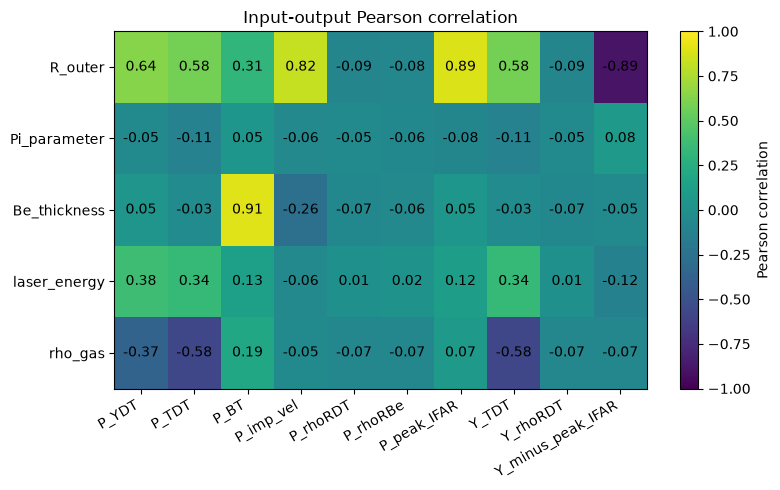

In [14]:

cols = input_cols + other_cols + objective_cols

corr = df[cols].corr(method="pearson")

# Extract only input-output block
input_output_corr = corr.loc[input_cols, other_cols + objective_cols]

plt.figure(figsize=(8, 5))
im = plt.imshow(input_output_corr, aspect="auto", vmin=-1, vmax=1)

plt.colorbar(im, label="Pearson correlation")
plt.xticks(np.arange(len(other_cols + objective_cols)), other_cols + objective_cols, rotation=30, ha="right")
plt.yticks(np.arange(len(input_cols)), input_cols)

# Write correlation values on the heatmap
for i in range(len(input_cols)):
    for j in range(len(other_cols + objective_cols)):
        value = input_output_corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.title("Input-output Pearson correlation")
plt.tight_layout()
plt.show()

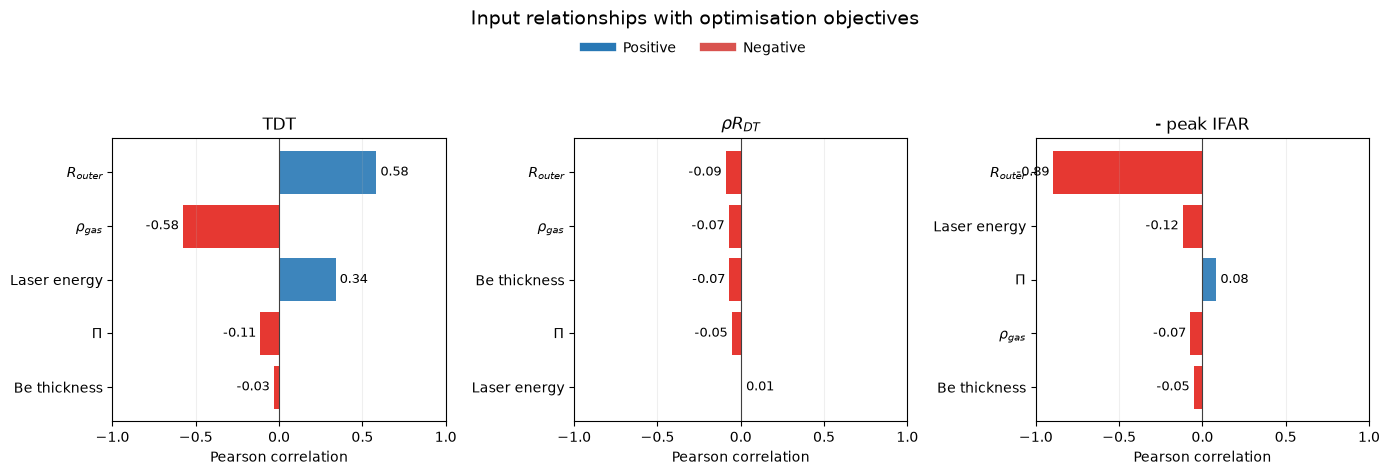

In [5]:

# Show the relationships that directly matter to the optimisation.
# Each panel ranks inputs by absolute correlation with one objective.
objective_corr = df[input_cols + objective_cols].corr().loc[input_cols, objective_cols]

objective_labels = {
    "Y_TDT": "TDT",
    "Y_rhoRDT": r"$\rho R_{DT}$",
    "Y_minus_peak_IFAR": "- peak IFAR",
}
input_labels = {
    "R_outer": r"$R_{outer}$",
    "Pi_parameter": r"$\Pi$",
    "Be_thickness": "Be thickness",
    "laser_energy": "Laser energy",
    "rho_gas": r"$\rho_{gas}$",
}

fig, axes = plt.subplots(1, len(objective_cols), figsize=(14, 4.8), sharex=True)

for ax, objective in zip(axes, objective_cols):
    values = objective_corr[objective].sort_values(key=np.abs)
    colors = np.where(values >= 0, "#2878B5", "#E4221C")
    bars = ax.barh(
        [input_labels[name] for name in values.index],
        values,
        color=colors,
        alpha=0.9,
    )
    ax.axvline(0, color="0.25", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(objective_labels[objective])
    ax.set_xlabel("Pearson correlation")
    ax.grid(axis="x", alpha=0.2)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

fig.suptitle("Input relationships with optimisation objectives", fontsize=14)
fig.legend(
    handles=[
        plt.Line2D([0], [0], color="#2878B5", lw=6, label="Positive"),
        plt.Line2D([0], [0], color="#D9534F", lw=6, label="Negative"),
    ],
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94),
)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()

In [6]:
hv = []

for n in range(1, Y.shape[0] + 1):
    Y_so_far = Y[:n]

    bd = DominatedPartitioning(
        ref_point=ref_point,
        Y=Y_so_far,
    )

    hv.append(bd.compute_hypervolume().item())

df["hypervolume"] = hv

In [7]:
df["hv_gain"] = df["hypervolume"].diff()
df.loc[0, "hv_gain"] = df.loc[0, "hypervolume"]

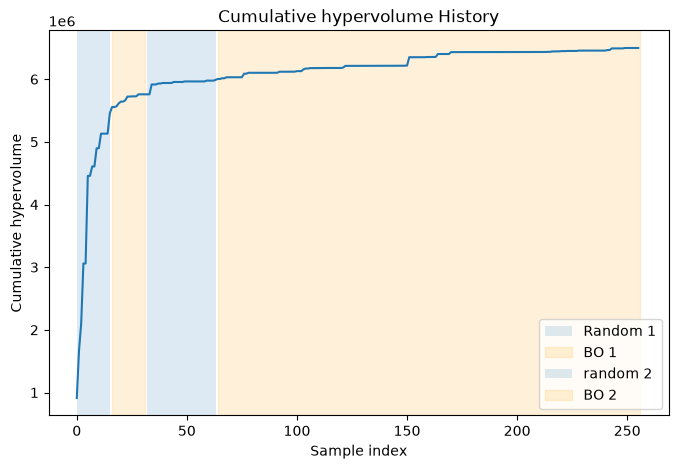

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(df["hypervolume"])
plt.axvspan(0, 15, alpha=0.15, label="Random 1")
plt.axvspan(16, 31, alpha=0.15, label="BO 1", color = "orange")
plt.axvspan(32, 63, alpha=0.15, label="random 2")
plt.axvspan(64, 256, alpha=0.15, label="BO 2", color = "orange")
plt.title("Cumulative hypervolume History")
plt.xlabel("Sample index")
plt.ylabel("Cumulative hypervolume")
plt.legend()
plt.show()

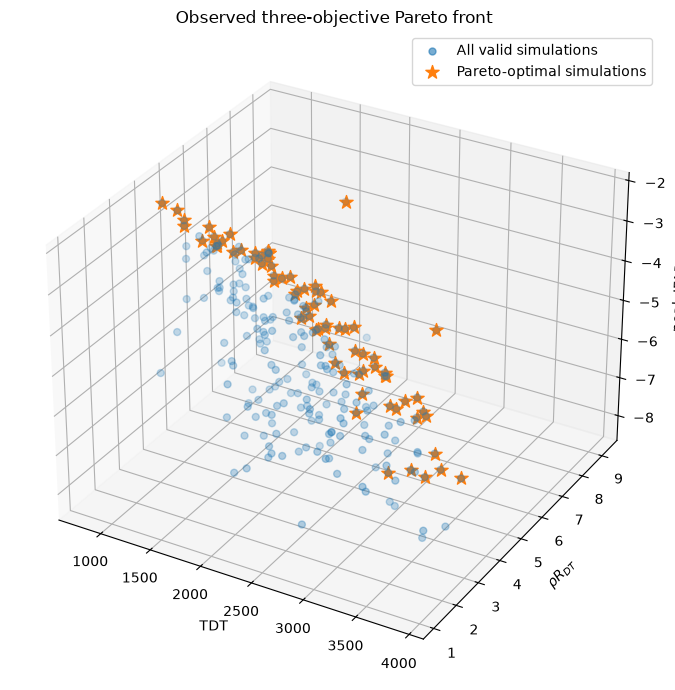

74 Pareto-optimal simulations out of 252 valid simulations.


,Y_TDT,Y_rhoRDT,Y_minus_peak_IFAR
151,3905.939944,3.223999,-6.331749
216,3745.339903,3.072769,-6.164238
249,3741.361277,2.381290,-5.979618
104,3591.643920,2.466602,-5.969045
34,3572.463175,3.631321,-6.195008
...,...,...,...
210,1011.977698,4.193962,-2.570306
199,1001.859715,5.541158,-3.834214
122,1001.140840,3.986903,-2.239216
115,929.184707,5.262563,-3.617285


In [9]:

from botorch.utils.multi_objective.pareto import is_non_dominated

# The three objectives in your database.
# All are maximised.
objective_cols = [
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
]

# Make a clean copy of the dataframe.
pareto_plot_df = df.copy()

# Exclude the clear rhoRDT outliers (indices 3, 5, and 164).
# Keep the raw database unchanged; this exclusion only affects Pareto plots.
outlier_indices = [3, 5, 164]
pareto_plot_df = pareto_plot_df[
    ~pareto_plot_df["index_0"].isin(outlier_indices)
].copy()


pareto_plot_df = pareto_plot_df[
    (pareto_plot_df["Y_TDT"] > 0)
    & (pareto_plot_df["Y_rhoRDT"] > 0)
    & np.isfinite(pareto_plot_df["Y_minus_peak_IFAR"])
].copy()

# Convert objectives into a tensor.
Y_plot = torch.tensor(
    pareto_plot_df[objective_cols].to_numpy(dtype=float),
    dtype=torch.double,
)

# Find the non-dominated points.
# BoTorch assumes every objective is maximised.
pareto_mask = is_non_dominated(Y_plot).cpu().numpy()

# Dataframe containing only Pareto-optimal simulations.
pareto_df = pareto_plot_df.loc[pareto_mask].copy()

# Plot all points and highlight the Pareto front.
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pareto_plot_df["Y_TDT"],
    pareto_plot_df["Y_rhoRDT"],
    pareto_plot_df["Y_minus_peak_IFAR"],
    alpha=0.6,
    s=25,
    label="All valid simulations",
)

ax.scatter(
    pareto_df["Y_TDT"],
    pareto_df["Y_rhoRDT"],
    pareto_df["Y_minus_peak_IFAR"],
    marker="*",
    s=100,
    depthshade=False,
    label="Pareto-optimal simulations",
)

ax.set_xlabel("TDT")
ax.set_ylabel(r"$\rho R_{DT}$")
ax.set_zlabel("- peak IFAR")

ax.set_title("Observed three-objective Pareto front")
ax.legend()

plt.tight_layout()
plt.show()

print(
    f"{len(pareto_df)} Pareto-optimal simulations "
    f"out of {len(pareto_plot_df)} valid simulations."
)

# Display the Pareto-optimal objective values.
display(
    pareto_df[objective_cols]
    .sort_values("Y_TDT", ascending=False)
)

### Inspect a Pareto (non-dominated) point

The table below gives each Pareto point both its plotted DataFrame index and its original database simulation index (`index_0`). Use either index with `inspect_dominating_point(...)` to recover the corresponding input parameters, objective values, and diagnostic outputs.


In [10]:
# Build an index lookup for the Pareto points found in the previous cell.
# "df_index" is the pandas row index used in the Pareto plot/table.
# "simulation_index" is the original database index stored in index_0.

def list_dominating_points(sort_by="Y_TDT", ascending=False):
    """Return a compact lookup table for all current Pareto points."""
    lookup = pareto_df.copy()
    lookup.insert(0, "df_index", lookup.index)

    if "index_0" in lookup.columns:
        lookup.insert(1, "simulation_index", lookup["index_0"])
    else:
        lookup.insert(1, "simulation_index", lookup.index)

    shown_cols = [
        "df_index",
        "simulation_index",
        *[col for col in input_cols if col in lookup.columns],
        *[col for col in objective_cols if col in lookup.columns],
    ]

    if sort_by not in lookup.columns:
        raise KeyError(
            f"sort_by={sort_by!r} is not a column. "
            f"Choose from: {list(lookup.columns)}"
        )

    return (
        lookup[shown_cols]
        .sort_values(sort_by, ascending=ascending)
        .reset_index(drop=True)
    )


def inspect_dominating_point(point_index, index_type="df_index"):
    """
    Inspect one Pareto/non-dominated simulation.

    Parameters
    ----------
    point_index : int or float
        Index identifying the simulation.
    index_type : {"df_index", "simulation_index", "pareto_position"}
        - "df_index": pandas row index used in the Pareto plot/table.
        - "simulation_index": original database index from index_0.
        - "pareto_position": zero-based row in list_dominating_points().

    Returns
    -------
    dict
        Selected row, input parameters, objective values, and diagnostics.
    """
    valid_index_types = {"df_index", "simulation_index", "pareto_position"}
    if index_type not in valid_index_types:
        raise ValueError(
            f"index_type must be one of {sorted(valid_index_types)}, "
            f"not {index_type!r}."
        )

    if index_type == "df_index":
        if point_index not in pareto_df.index:
            raise KeyError(
                f"DataFrame index {point_index!r} is not on the current Pareto front. "
                "Run display(list_dominating_points()) to see valid indices."
            )
        df_index = point_index
        row = pareto_df.loc[df_index]

    elif index_type == "simulation_index":
        if "index_0" not in pareto_df.columns:
            raise KeyError("The dataframe has no index_0 database-index column.")

        matches = pareto_df.index[pareto_df["index_0"] == point_index].tolist()
        if not matches:
            raise KeyError(
                f"Simulation index {point_index!r} is not on the current Pareto front. "
                "Run display(list_dominating_points()) to see valid indices."
            )
        if len(matches) > 1:
            raise ValueError(
                f"Simulation index {point_index!r} appears more than once: {matches}."
            )

        df_index = matches[0]
        row = pareto_df.loc[df_index]

    else:  # pareto_position
        lookup = list_dominating_points()
        position = int(point_index)

        if position != point_index:
            raise ValueError("pareto_position must be a whole number.")

        if position < 0 or position >= len(lookup):
            raise IndexError(
                f"pareto_position must be between 0 and {len(lookup) - 1}."
            )

        df_index = lookup.loc[position, "df_index"]
        row = pareto_df.loc[df_index]

    simulation_index = row["index_0"] if "index_0" in row.index else df_index

    inputs = row[[col for col in input_cols if col in row.index]].copy()
    inputs.name = "value"

    objectives = row[[col for col in objective_cols if col in row.index]].copy()
    objectives.name = "value"

    diagnostics = row[[col for col in other_cols if col in row.index]].copy()
    diagnostics.name = "value"

    print(f"DataFrame index: {df_index}")
    print(f"Database simulation index (index_0): {simulation_index}")

    print("\nInput parameters:")
    display(inputs.to_frame())

    print("Objective values:")
    display(objectives.to_frame())

    if not diagnostics.empty:
        print("Diagnostic outputs:")
        display(diagnostics.to_frame())

    return {
        "df_index": df_index,
        "simulation_index": simulation_index,
        "row": row,
        "inputs": inputs,
        "objectives": objectives,
        "diagnostics": diagnostics,
    }


# First inspect this table to find the point/index you want.
display(list_dominating_points())

# Examples:
# result = inspect_dominating_point(35, index_type="df_index")
# result = inspect_dominating_point(35, index_type="simulation_index")
# result = inspect_dominating_point(0, index_type="pareto_position")


,df_index,simulation_index,R_outer,Pi_parameter,Be_thickness,laser_energy,rho_gas,Y_TDT,Y_rhoRDT,Y_minus_peak_IFAR
0,151,151,0.003198,1.204314e-07,0.000075,1306.612934,0.905226,3905.939944,3.223999,-6.331749
1,216,216,0.003161,1.206223e-07,0.000085,1914.211093,2.986005,3745.339903,3.072769,-6.164238
2,249,249,0.003064,1.207407e-07,0.000165,1796.388693,1.172862,3741.361277,2.381290,-5.979618
3,104,104,0.003022,1.181143e-07,0.000190,1367.785236,1.585914,3591.643920,2.466602,-5.969045
4,34,34,0.003169,1.207283e-07,0.000085,922.882679,2.064523,3572.463175,3.631321,-6.195008
...,...,...,...,...,...,...,...,...,...,...
69,210,210,0.002610,1.226904e-07,0.000070,1301.750644,6.833250,1011.977698,4.193962,-2.570306
70,199,199,0.002743,1.220562e-07,0.000050,422.689556,9.092618,1001.859715,5.541158,-3.834214
71,122,122,0.002609,1.208266e-07,0.000100,653.522946,5.657796,1001.140840,3.986903,-2.239216
72,115,115,0.002672,1.221572e-07,0.000135,622.937179,9.980558,929.184707,5.262563,-3.617285


In [11]:
# Create and display the table
pareto_table = list_dominating_points()
display(pareto_table)

# Save the table as CSV
pareto_table.to_csv(
    "pareto_dominating_points.csv",
    index=False,
)

print("Saved as: pareto_dominating_points.csv")

,df_index,simulation_index,R_outer,Pi_parameter,Be_thickness,laser_energy,rho_gas,Y_TDT,Y_rhoRDT,Y_minus_peak_IFAR
0,151,151,0.003198,1.204314e-07,0.000075,1306.612934,0.905226,3905.939944,3.223999,-6.331749
1,216,216,0.003161,1.206223e-07,0.000085,1914.211093,2.986005,3745.339903,3.072769,-6.164238
2,249,249,0.003064,1.207407e-07,0.000165,1796.388693,1.172862,3741.361277,2.381290,-5.979618
3,104,104,0.003022,1.181143e-07,0.000190,1367.785236,1.585914,3591.643920,2.466602,-5.969045
4,34,34,0.003169,1.207283e-07,0.000085,922.882679,2.064523,3572.463175,3.631321,-6.195008
...,...,...,...,...,...,...,...,...,...,...
69,210,210,0.002610,1.226904e-07,0.000070,1301.750644,6.833250,1011.977698,4.193962,-2.570306
70,199,199,0.002743,1.220562e-07,0.000050,422.689556,9.092618,1001.859715,5.541158,-3.834214
71,122,122,0.002609,1.208266e-07,0.000100,653.522946,5.657796,1001.140840,3.986903,-2.239216
72,115,115,0.002672,1.221572e-07,0.000135,622.937179,9.980558,929.184707,5.262563,-3.617285


Saved as: pareto_dominating_points.csv


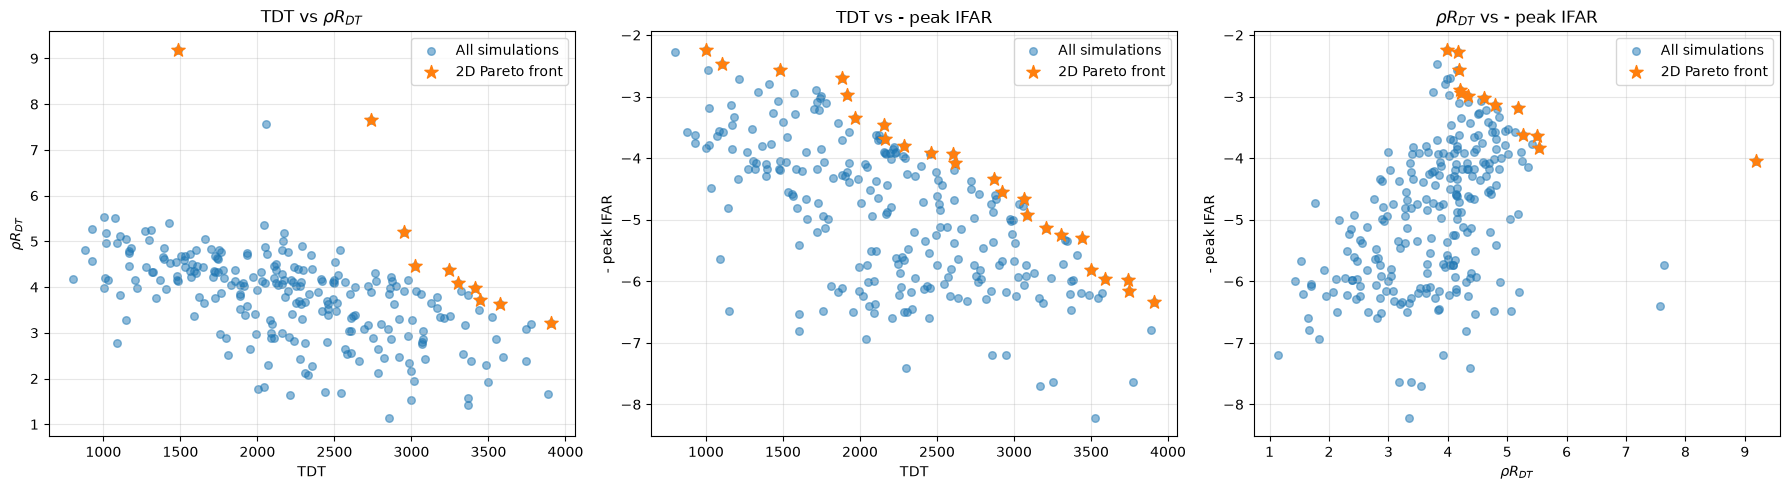

In [12]:

from itertools import combinations


objective_cols = [
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
]

objective_labels = {
    "Y_TDT": "TDT",
    "Y_rhoRDT": r"$\rho R_{DT}$",
    "Y_minus_peak_IFAR": "- peak IFAR",
}


objective_pairs = list(combinations(objective_cols, 2))

fig, axes = plt.subplots(
    1,
    len(objective_pairs),
    figsize=(18, 5),
)

for ax, (x_col, y_col) in zip(axes, objective_pairs):

    # Extract the current pair of objectives.
    Y_pair = torch.tensor(
        pareto_plot_df[[x_col, y_col]].to_numpy(dtype=float),
        dtype=torch.double,
    )

    # Recalculate the Pareto front using only these two objectives.
    pair_pareto_mask = is_non_dominated(Y_pair).cpu().numpy()

    pair_pareto_df = pareto_plot_df.loc[pair_pareto_mask].copy()

    # Sort by the x objective so the Pareto-front line is drawn correctly.
    pair_pareto_df = pair_pareto_df.sort_values(x_col)

    # Plot all valid simulations.
    ax.scatter(
        pareto_plot_df[x_col],
        pareto_plot_df[y_col],
        alpha=0.5,
        s=30,
        label="All simulations",
    )

    # Plot the 2D Pareto-optimal points.
    ax.scatter(
        pair_pareto_df[x_col],
        pair_pareto_df[y_col],
        marker="*",
        s=100,
        label="2D Pareto front",
        zorder=3,
    )

    ax.set_xlabel(objective_labels[x_col])
    ax.set_ylabel(objective_labels[y_col])

    ax.set_title(
        f"{objective_labels[x_col]} vs "
        f"{objective_labels[y_col]}"
    )

    ax.grid(alpha=0.3)
    ax.legend()


# axes[0].set_ylim(0,20)
# axes[2].set_xlim(0,20)
plt.tight_layout()
plt.show()

(# simulation samples, # variables)
Samples shape: (256, 8)


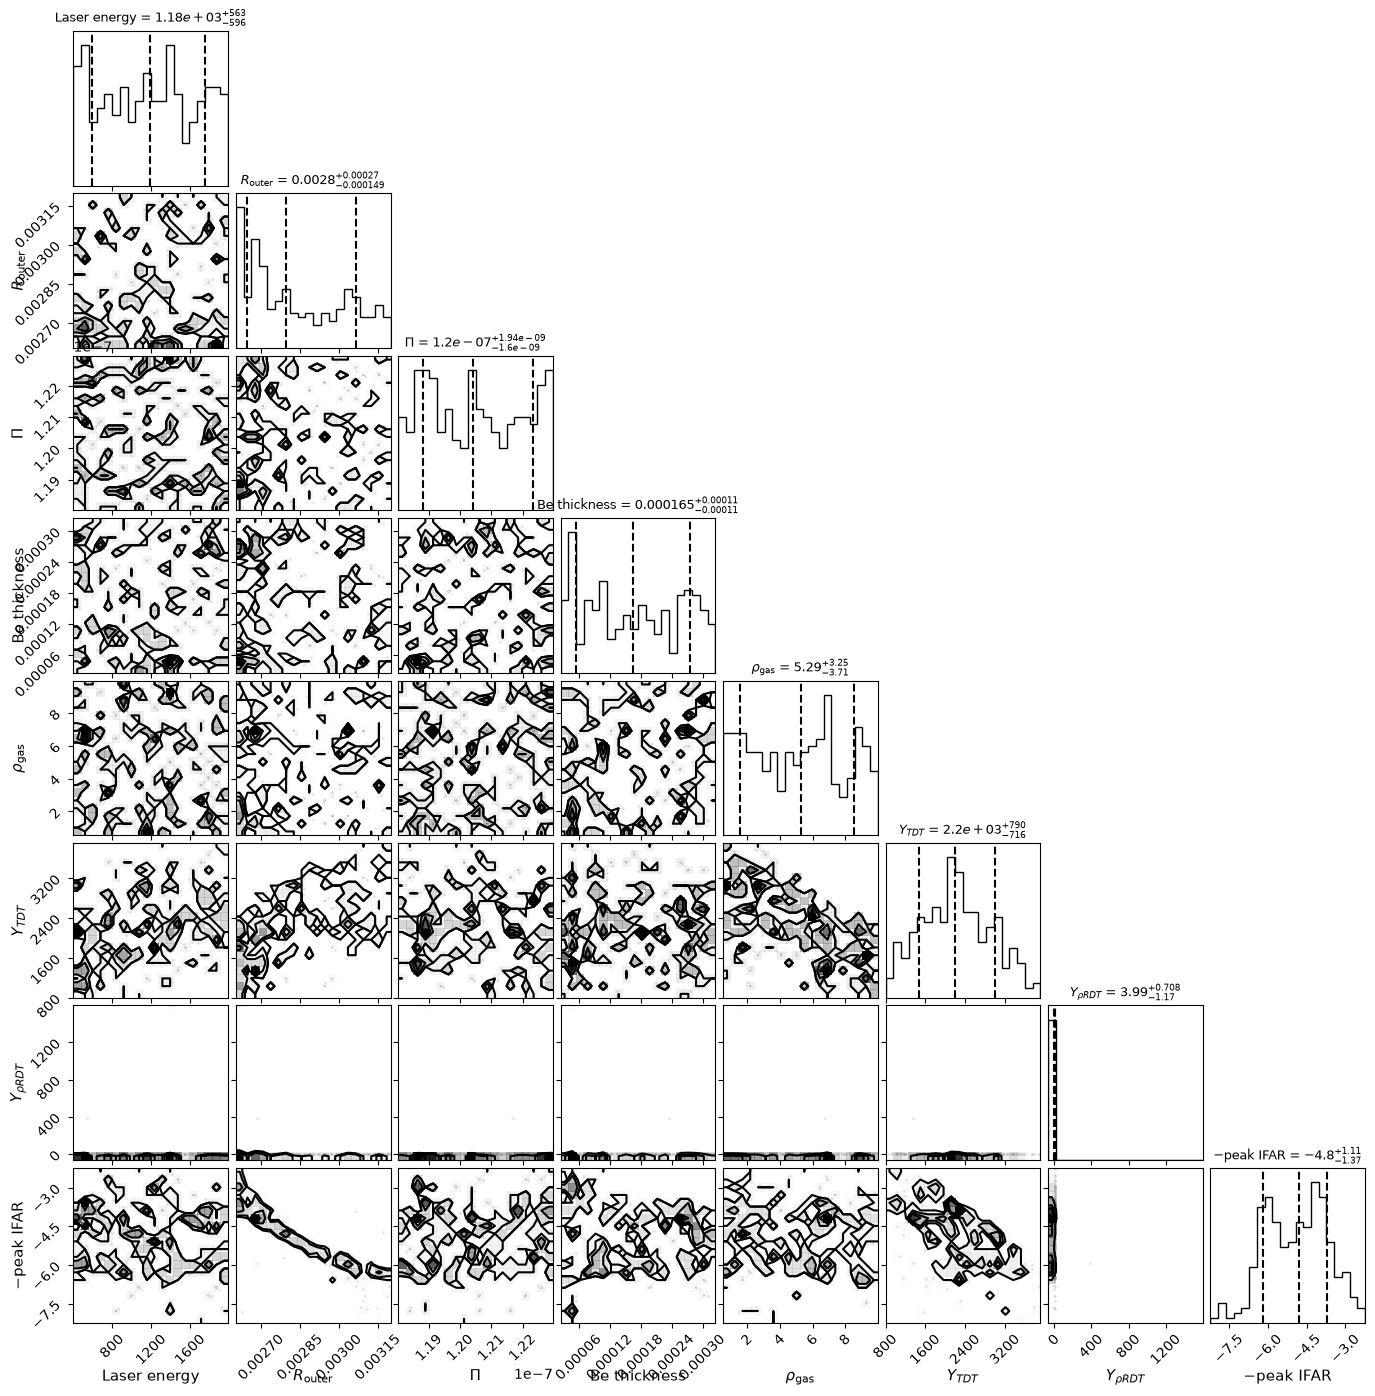

In [13]:

import corner

corner_cols = [
    "laser_energy",
    "R_outer",
    "Pi_parameter",
    "Be_thickness",
    "rho_gas",
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
]

# Convert to numeric and remove invalid rows
corner_df = (
    df[corner_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Each row is one simulation, and each column is one parameter/objective
samples = corner_df.to_numpy()

print("(# simulation samples, # variables)")
print("Samples shape:", samples.shape)

labels = [
    "Laser energy",
    r"$R_{\mathrm{outer}}$",
    r"$\Pi$",
    "Be thickness",
    r"$\rho_{\mathrm{gas}}$",
    r"$Y_{TDT}$",
    r"$Y_{\rho RDT}$",
    r"$-\mathrm{peak\ IFAR}$",
]

fig = corner.corner(
    samples,
    labels=labels,
    bins=20,
    show_titles=True,
    title_fmt=".3g",
    plot_datapoints=True,
    plot_density=True,
    fill_contours=False,
    quantiles=[0.16, 0.50, 0.84],
    label_kwargs={"fontsize": 11},
    title_kwargs={"fontsize": 9},
)

fig.set_size_inches(14, 14)
plt.show()